# Challenge 2
This challenge is about OSMnx. You will explore and analyze a city's street network using the OSMnx Python library.

1. Use OSMnx to download the street network of a city of your choice. You can specify the city name, BBox or a Dict.
2. Calculate basic statistics for the street network, such as the number of nodes, edges, average node degree, etc.
3. Use OSMnx to plot the street network. Customize the plot to make it visually appealing, including node size, edge color. See the potential options here: https://osmnx.readthedocs.io/en/stable/user-reference.html#module-osmnx.plot
4. Utilize the routing capabilities of OSMnx to find the shortest path between two points in the street network. Plot the route on top of the street network.
5. Calculate the centrality measures (e.g., degree centrality and betweenness_centrality) for nodes in the street network.
6. Create the figure-groud from the selected city
7. Create interactive maps to plot nodes, edges, nodes+edges and one of the centrality measures.
8. Export the street network to a GeoPackage (.gpkg) file. Ensure that the exported file contains both node and edge attributes. Demonstrate that the new GeoPackage can be used and read in Python using any of the libraries we have seen in the class to create a simple and interactive map.
9. Finally, use OSMnx to extract other urban elements (e.g., buildings, parks) and plot them.

In [1]:
import networkx as nx
import osmnx as ox

In [2]:
#run this once
#!pip install osmnx

In [3]:
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
warnings.filterwarnings('ignore')

In [4]:
#downloading our chosen street network of Carmel, Indiana, USA
# through making a query in the form of a dict
place = {"city": "Carmel", "state": "Indiana", "country": "USA"}
G = ox.graph_from_place(place, network_type="drive", truncate_by_edge=True)

In [5]:
#calculating basic statistics for the street network, such as number of nodes, edges, average node degree etc.

In [6]:
#calculating number of nodes
print("The graph has", len(G.nodes), "nodes")

#calculating number of edges
print("The graph has", len(G.edges), "edges")

The graph has 6112 nodes
The graph has 13688 edges


In [7]:
#exploring the data type of nodes
print("The nodes are", print(type(G.nodes)))

<class 'networkx.classes.reportviews.NodeView'>
The nodes are None


In [8]:
#exploring the data type of edges
print("The edges are", print(type(list(G.edges(data=True))[0])))

<class 'tuple'>
The edges are None


In [9]:
#exploring elements of the first and last nodes
print(list(G.nodes(data=True))[0])
print(list(G.nodes(data=True))[-1])

(178882025, {'y': 39.9503101, 'x': -86.2407299, 'street_count': 3})
(12706681920, {'y': 39.9995797, 'x': -86.162231, 'street_count': 2})


In [10]:
#exploring elements of the first and last edges
print(list(G.edges(data=True))[0])
print(list(G.edges(data=True))[-1])

(178882025, 178882035, {'osmid': 17263174, 'highway': 'residential', 'name': 'Tillson Drive', 'oneway': False, 'reversed': False, 'length': np.float64(388.65363766939737), 'geometry': <LINESTRING (-86.241 39.95, -86.241 39.95, -86.241 39.95, -86.241 39.95, -86...>})
(12706681920, 179782043, {'osmid': 1178222798, 'highway': 'residential', 'oneway': True, 'reversed': False, 'length': np.float64(55.36129263604355), 'geometry': <LINESTRING (-86.162 40, -86.162 40, -86.162 40, -86.162 40, -86.162 40, -86...>})


In [ ]:
#calculating average node degree 
#warning - very large cell output - 

#only run once

nx.average_neighbor_degree(G, weight="weight")

In [39]:
#showing only a few results
avg_neighbor_degree = nx.average_neighbor_degree(G, weight="weight")

for node, value in list(avg_neighbor_degree.items())[:5]:
    print(f"Node {node}: {value}")

Node 178878550: 2.0
Node 178882025: 2.3333333333333335
Node 178882035: 3.0
Node 178884861: 3.0
Node 178884864: 3.0


In [43]:
#filtering for a few that are above the threshold of 3
threshold = 3
filtered_results = {node: degree for node, degree in avg_neighbor_degree.items() if degree > threshold}

print(filtered_results)

{178888794: 3.3333333333333335, 2428527443: 3.25, 2428527448: 3.3333333333333335, 7689096149: 3.5}


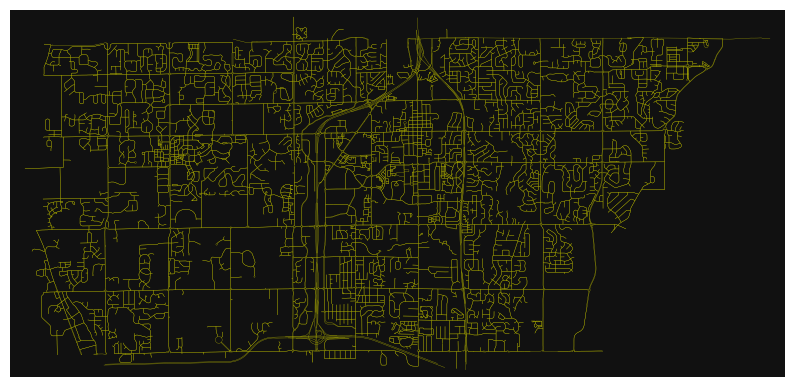

In [12]:
#plotting street network using OSMnx
fig, ax = ox.plot_graph(G, figsize=(10, 10), node_size=0, edge_color="y", edge_linewidth=0.2)

In [13]:
#customising the node size and edge color

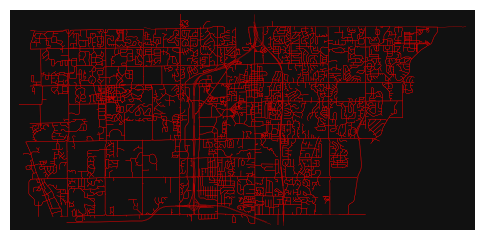

In [14]:
#first experiment, changing the color and figure size
fig, ax = ox.plot_graph(G, figsize=(6, 6), node_size=0, edge_color="r", edge_linewidth=0.2)

In [15]:
#NOTE = this code takes extremely long to load, so run the rest of the code first then attempt to run this 
#second experiment, visualising street centrality using color - defining edge centrality and ev

#edge_centrality = nx.closeness_centrality(nx.line_graph(G))
#ev = [edge_centrality[edge + (0,)] for edge in G.edges()]

#norm = colors.Normalize(vmin=min(ev)*0.8, vmax=max(ev)) #converting the color scale to a list of colors for graph edges
#cmap = cm.ScalarMappable(norm=norm, cmap=cm.inferno)
#ec = [cmap.to_rgba(cl) for cl in ev]

# coloring the edges with closeness centralities in the line graph
#fig, ax = ox.plot_graph(G, bgcolor='k', axis_off=True, node_size=0,
                        #edge_color=ec, edge_linewidth=1.5, edge_alpha=1)

Reference: gboeing (2017). osmnx-examples/notebooks/00-osmnx-features-demo.ipynb at v0.13.0 · gboeing/osmnx-examples. [online] GitHub. Available at: https://github.com/gboeing/osmnx-examples/blob/v0.13.0/notebooks/00-osmnx-features-demo.ipynb [Accessed 16 Mar. 2025].

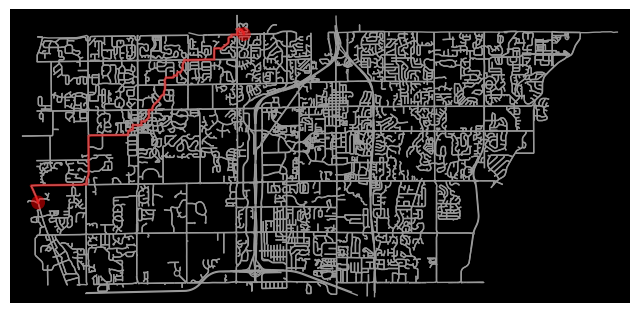

In [16]:
#utilise the routing capabilities of OSMnx to find the shortest path between two points 

#establishing origin
orig = list(G)[0]

#establishing destination
dest = list(G)[-1]

#plot the route
route = nx.shortest_path(G, orig, dest, weight='length')
fig, ax = ox.plot_graph_route(G, route, route_linewidth=2, node_size=0, bgcolor='k')

Reference: Geoff Boeing. (2016). OSMnx: Python for Street Networks. [online] Available at: https://geoffboeing.com/2016/11/osmnx-python-street-networks/.

In [ ]:
#calculating centrality measures
#calculating degree centrality
degree_centrality = nx.degree_centrality(G)
for node, centrality in degree_centrality.items():
    print(f"Node {node}: Degree Centrality = {centrality: .3f}")
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='skyblue')
plt.title('Graph G with Degree Centrality')
plt.show()

In [50]:
#calculating average degree centrality for the network
import numpy as np
degree_avg = sum(degree_centrality.values()) / len(degree_centrality)
degree_values = list(degree_centrality.values())
print(f"Min: {np.min(degree_values):.3f}, Max: {np.max(degree_values):.3f}, Mean: {np.mean(degree_values):.3f}, Median: {np.median(degree_values):.3f}")
print(f"Average Degree Centrality: {degree_avg:.3f}")

Min: 0.010, Max: 0.078, Mean: 0.045, Median: 0.058
Average Degree Centrality: 0.045


In [51]:
# show only the top 5 nodes with highest degree centrality
top_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 Nodes by Degree Centrality:")
for node, centrality in top_nodes:
    print(f"Node {node}: Degree Centrality = {centrality:.3f}")


Top 5 Nodes by Degree Centrality:
Node 178884871: Degree Centrality = 0.078
Node 2428527443: Degree Centrality = 0.078
Node 7536895300: Degree Centrality = 0.078
Node 178882025: Degree Centrality = 0.058
Node 178884864: Degree Centrality = 0.058


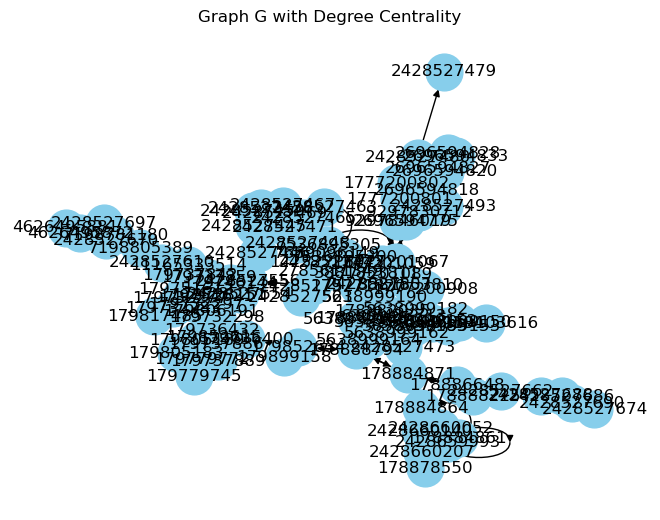

In [52]:
# drawing the graph of degree centralities
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=700, node_color='skyblue')
plt.title('Graph G with Degree Centrality')
plt.show()

In [48]:
#calculating average betweenness centrality for the network
import osmnx as ox
import networkx as nx

betweenness_centrality = nx.betweenness_centrality(G)

betweenness_avg = sum(betweenness_centrality.values()) / len(betweenness_centrality)

print(f"Average Betweenness Centrality: {betweenness_avg:.5f}")

Average Betweenness Centrality: 0.08274


In [18]:
#creating figure-ground diagram from Carmel
import osmnx as ox
from IPython.display import Image

In [19]:
#configuring the inline image display
img_folder = "images"
extension = "png"
size = 240
dpi = 40

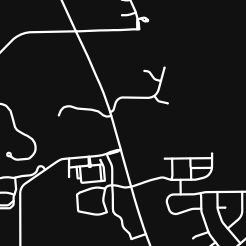

In [20]:
#picking a point in Carmel to display
place = 'Carmel'
point=(39.9503101, -86.2407299)
fp = f"./{img_folder}/{place}.{extension}"

G = ox.graph_from_point(point, dist=1000, network_type='drive')

fig, ax = ox.plot_figure_ground(
    G,
    filepath=fp,
    dpi=dpi,
    save=True,
    show=False,
    close=True,
)
Image(fp, height=size, width=size)

Reference: gboeing (2017). osmnx-examples/notebooks/09-example-figure-ground.ipynb at v0.11 · gboeing/osmnx-examples. [online] GitHub. Available at: https://github.com/gboeing/osmnx-examples/blob/v0.11/notebooks/09-example-figure-ground.ipynb [Accessed 16 Mar. 2025].

In [21]:
#creating interactive maps to plot nodes, edges, nodes+edges and one of centrality measures

In [22]:
# exploring graph edges interactively, with a simple one-liner
ox.graph_to_gdfs(G, nodes=False).explore()

In [23]:
# exploring graph nodes interactively, with different basemap tiles
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.explore(tiles="cartodbpositron", marker_kwds={"radius": 8})

In [24]:
# exploring nodes and edges together in a single map
nodes, edges = ox.graph_to_gdfs(G)
m = edges.explore(color="skyblue", tiles="cartodbdarkmatter")
nodes.explore(m=m, color="pink", marker_kwds={"radius": 6})

In [25]:
# exploring graph edges interactively, colored by length
edges.explore(tiles="cartodbdarkmatter", column="length", cmap="plasma")

In [26]:
# exploring graph nodes interactively, colored by betweenness centrality
nx.set_node_attributes(G, nx.betweenness_centrality(G, weight="length"), name="bc")
nodes = ox.graph_to_gdfs(G, edges=False)
nodes.explore(tiles="cartodbdarkmatter", column="bc", marker_kwds={"radius": 8})

In [27]:
#exporting street network to a geopackage file
ox.save_graph_geopackage(G, filepath="./data/mynetwork.gpkg")
ox.save_graphml(G, filepath="./data/mynetwork.graphml")

In [28]:
#reading the geopackage file in python
read = "./data/mynetwork.gpkg"

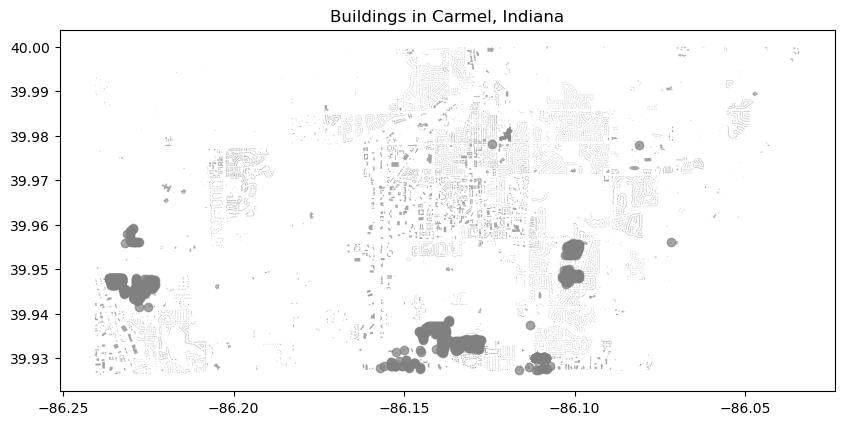

In [29]:
#using OSMnx to extract other urban elements e.g. buildings, parks and plotting them
import matplotlib.pyplot as plt

place_name = "Carmel, Indiana, USA"
buildings = ox.features_from_place(place_name, tags={"building": True})
fig, ax = plt.subplots(figsize=(10, 10))
buildings.plot(ax=ax, color="gray", alpha=0.7)
plt.title("Buildings in Carmel, Indiana")
plt.show()

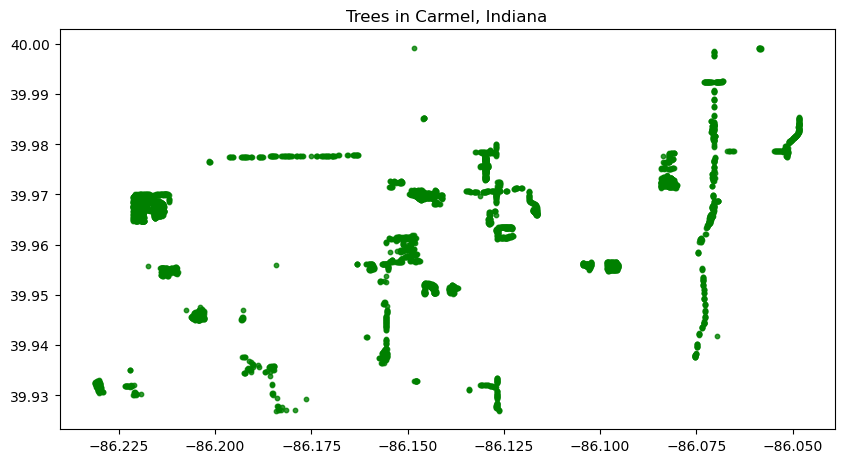

In [30]:
trees = ox.features_from_place(place_name, tags={"natural": "tree"})

fig, ax = plt.subplots(figsize=(10, 10))
trees.plot(ax=ax, color="green", markersize=10, alpha=0.8)
plt.title("Trees in Carmel, Indiana")
plt.show()

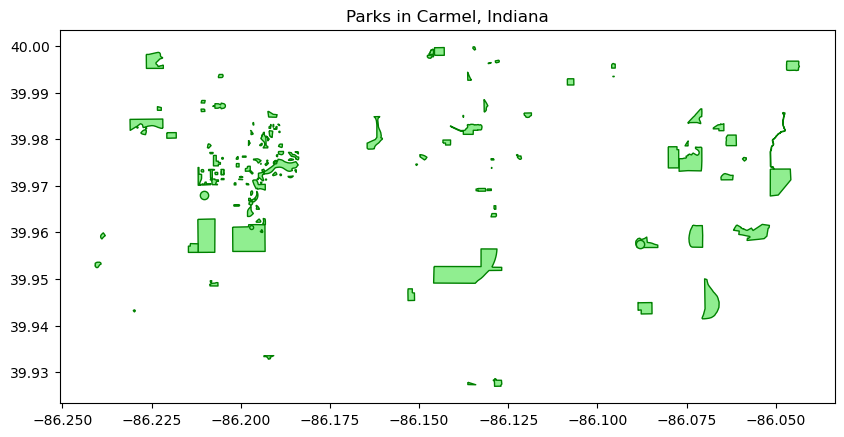

In [31]:
parks = ox.features_from_place(place_name, tags={"leisure": "park"})

fig, ax = plt.subplots(figsize=(10, 10))
parks.plot(ax=ax, color="lightgreen", edgecolor="green", linewidth=1)
plt.title("Parks in Carmel, Indiana")
plt.show()